<a href="https://colab.research.google.com/github/Sharu-052897/deep-learning/blob/main/CNN_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [ ]:
train_mask = (y_train.flatten() == 3) | (y_train.flatten() == 5)
test_mask = (y_test.flatten() == 3) | (y_test.flatten() == 5)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

In [ ]:
y_train = (y_train.flatten() == 5).astype(int)
y_test = (y_test.flatten() == 5).astype(int)

print("Cat = 0")
print("Dog = 1")

Cat = 0
Dog = 1


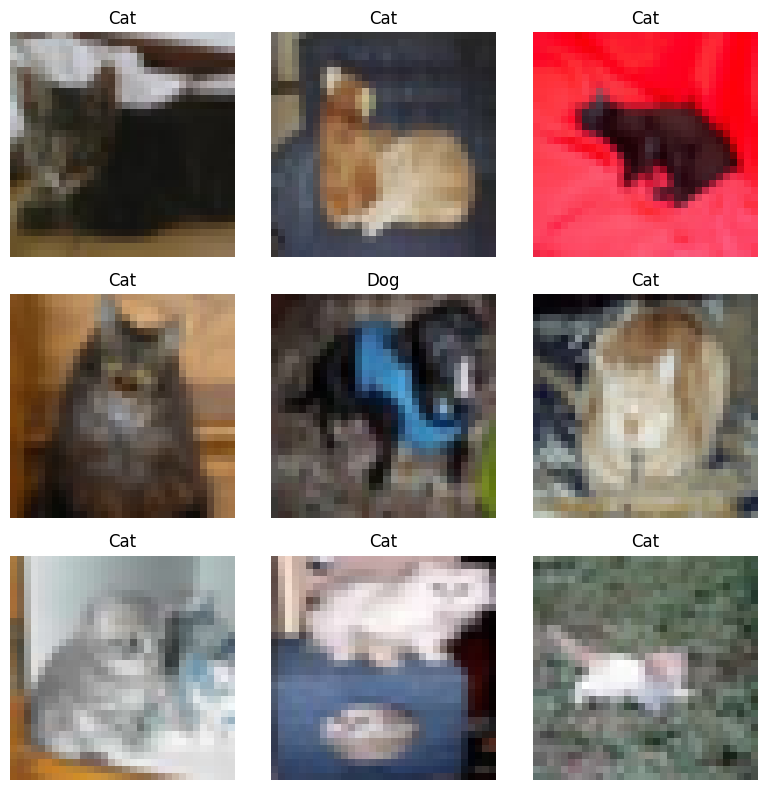

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(X_train[i])

    if y_train[i] == 0:
        label = "Cat"
    else:
        label = "Dog"

    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
model = keras.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=20,
    validation_split=0.2
)

Epoch 1/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.6590 - loss: 0.6164 - val_accuracy: 0.6155 - val_loss: 0.6357
Epoch 2/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.7115 - loss: 0.5615 - val_accuracy: 0.7135 - val_loss: 0.5695
Epoch 3/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.7415 - loss: 0.5186 - val_accuracy: 0.7240 - val_loss: 0.5430
Epoch 4/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.7685 - loss: 0.4779 - val_accuracy: 0.7430 - val_loss: 0.5218
Epoch 5/5
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.7950 - loss: 0.4302 - val_accuracy: 0.7470 - val_loss: 0.5606


In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

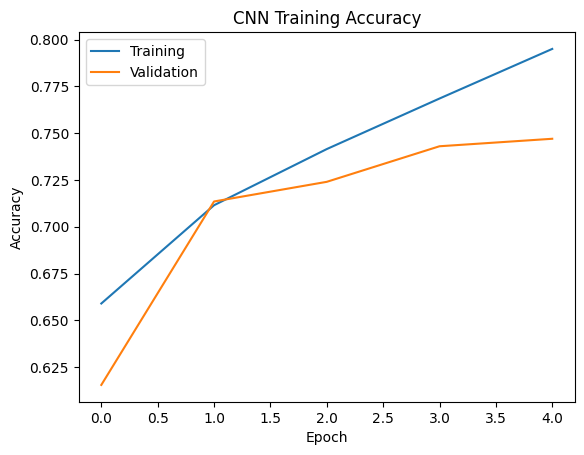

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")

plt.legend(["Training", "Validation"])

plt.show()

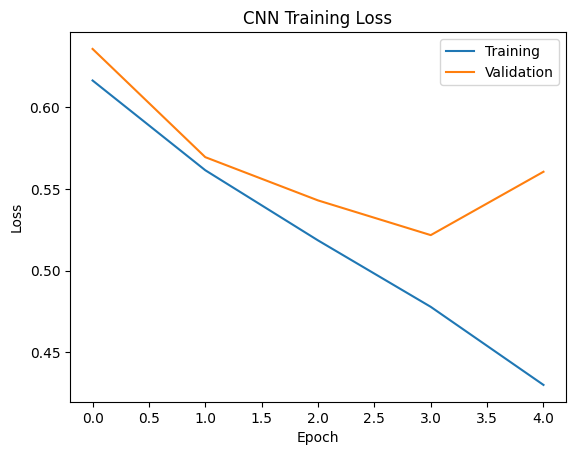

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.legend(["Training", "Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


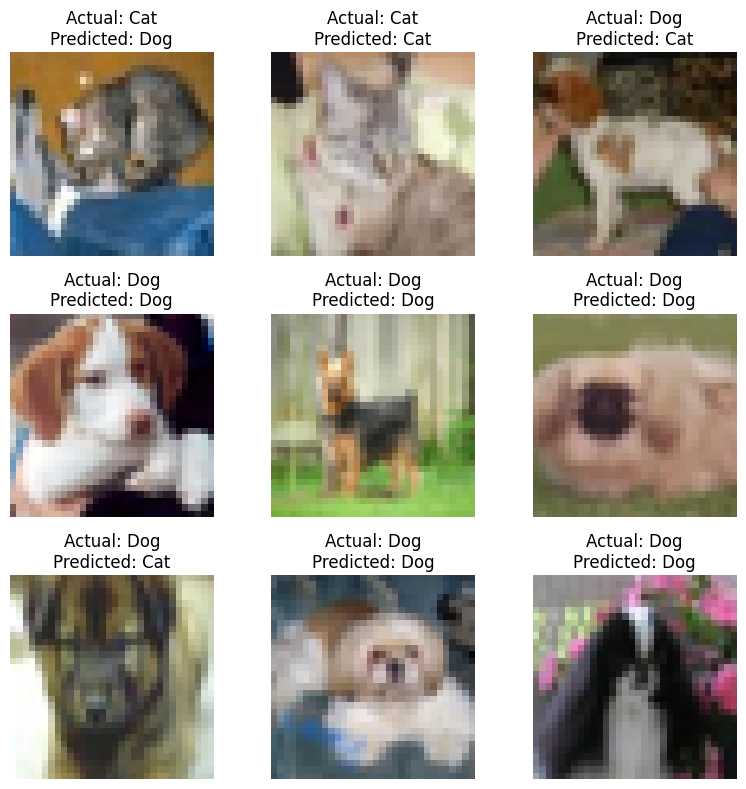

In [ ]:
predictions = model.predict(X_test[:9])

plt.figure(figsize=(8, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_test[i])

    if predictions[i][0] >= 0.5:
        predicted = "Dog"
    else:
        predicted = "Cat"

    if y_test[i] == 0:
        actual = "Cat"
    else:
        actual = "Dog"

    plt.title(
        "Actual: " + actual +
        "\nPredicted: " + predicted
    )

    plt.axis("off")

plt.tight_layout()
plt.show()